In [3]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix
from sklearn.preprocessing import LabelEncoder
from xgboost import XGBClassifier
from sklearn.model_selection import cross_val_score
from sklearn.metrics import roc_auc_score

In [4]:
df=pd.read_csv(r"C:\Users\ssham\intern-performance-project\intern_performance_cleaned.csv")
print(df.shape)
print(df.head())
print(df.columns.tolist())

(1000, 6)
  Intern_ID  Completion_Time  Feedback_Rating  Attendance  Performance_Score  \
0   INT0001         3.260000         4.090000       86.50              70.98   
1   INT0002         3.928256         1.330000       59.23              42.16   
2   INT0003         5.780000         2.933667       42.98              49.89   
3   INT0004         4.280000         1.430000       83.16              68.49   
4   INT0005         1.530000         1.910000       74.10              77.51   

  performance_label  
0              High  
1               Low  
2               Low  
3            Medium  
4              High  
['Intern_ID', 'Completion_Time', 'Feedback_Rating', 'Attendance', 'Performance_Score', 'performance_label']


In [5]:
X = df[['Completion_Time', 'Feedback_Rating', 'Attendance']]
y=df['performance_label']
print(X.shape)
print(y.shape)
le=LabelEncoder()
y=le.fit_transform(y)
print(y[:10])
print(le.classes_)

(1000, 3)
(1000,)
[0 1 1 2 0 0 0 2 0 2]
['High' 'Low' 'Medium']


In [6]:
X_train, X_test, y_train, y_test=train_test_split(X, y, test_size=0.2, random_state=42)
print("X_train:",X_train.shape)
print("X_test:",X_test.shape)
print("y_train:",y_train.shape)
print("y_test:",y_test.shape)

X_train: (800, 3)
X_test: (200, 3)
y_train: (800,)
y_test: (200,)


In [7]:
rf=RandomForestClassifier(n_estimators=200, max_depth=10, min_samples_split=5, random_state=42) 
rf.fit(X_train,y_train) 
rf_predictions=rf.predict(X_test) 
rf_accuracy=accuracy_score(y_test, rf_predictions)
print("Accuracy Score", rf_accuracy) 
print("Classification Report") 
print("Classification Report:",classification_report(y_test, rf_predictions, target_names=le.classes_))

Accuracy Score 0.665
Classification Report
Classification Report:               precision    recall  f1-score   support

        High       0.72      0.77      0.74        94
         Low       0.64      0.43      0.51        21
      Medium       0.60      0.61      0.61        85

    accuracy                           0.67       200
   macro avg       0.66      0.60      0.62       200
weighted avg       0.66      0.67      0.66       200



In [8]:
rf_cv=cross_val_score(rf,X,y,cv=5)
print("Random Forest Cross Validation Scores:",rf_cv)
print("Random Forest Mean Cross Validation Accuracy:",rf_cv.mean().round(2))
rf_auc=roc_auc_score(y_test, rf.predict_proba(X_test), multi_class='ovr')
print("Random Forest AUC Score:", round(rf_auc,2))

Random Forest Cross Validation Scores: [0.695 0.67  0.655 0.615 0.665]
Random Forest Mean Cross Validation Accuracy: 0.66
Random Forest AUC Score: 0.83


In [9]:
xgb=XGBClassifier(n_estimators=200, learning_rate=0.1, max_depth=6, random_state=42, eval_metric='mlogloss') 
xgb.fit(X_train, y_train) 
xgb_predictions = xgb.predict(X_test) 
xgb_accuracy = accuracy_score(y_test, xgb_predictions)
print("Accuracy Score", xgb_accuracy)  
print("Classification Report") 
print("Classification Report:", classification_report(y_test, xgb_predictions, target_names=le.classes_))

Accuracy Score 0.645
Classification Report
Classification Report:               precision    recall  f1-score   support

        High       0.73      0.77      0.75        94
         Low       0.45      0.43      0.44        21
      Medium       0.59      0.56      0.58        85

    accuracy                           0.65       200
   macro avg       0.59      0.59      0.59       200
weighted avg       0.64      0.65      0.64       200



In [10]:
xgb_cv=cross_val_score(xgb, X, y, cv=5)
print("XGBoost Cross Validation Scores:",xgb_cv)
print("XGBoost Mean Cross Validation Accuracy:", xgb_cv.mean().round(2))
xgb_auc=roc_auc_score(y_test,xgb.predict_proba(X_test),multi_class='ovr')
print("XGBoost AUC Score:",round(xgb_auc,2))

XGBoost Cross Validation Scores: [0.65  0.655 0.635 0.61  0.685]
XGBoost Mean Cross Validation Accuracy: 0.65
XGBoost AUC Score: 0.81


In [11]:
results = { 
    'Model' : ['Random Forest', 'XGBoost'],
    'Accuracy' : [rf_accuracy, xgb_accuracy],
    'CV Score' : [rf_cv.mean().round(2), xgb_cv.mean().round(2)],
    'AUC Score': [round(rf_auc, 2), round(xgb_auc, 2)]
}
results_df=pd.DataFrame(results)
results_df['Accuracy']=results_df['Accuracy'].round(2)
results_df=results_df.sort_values('Accuracy', ascending=False)
print("Model Comparison")
print(results_df)
print("\nBest Model:", results_df.iloc[0]['Model'])
print("Best Accuracy:", results_df.iloc[0]['Accuracy'])

Model Comparison
           Model  Accuracy  CV Score  AUC Score
0  Random Forest      0.66      0.66       0.83
1        XGBoost      0.64      0.65       0.81

Best Model: Random Forest
Best Accuracy: 0.66


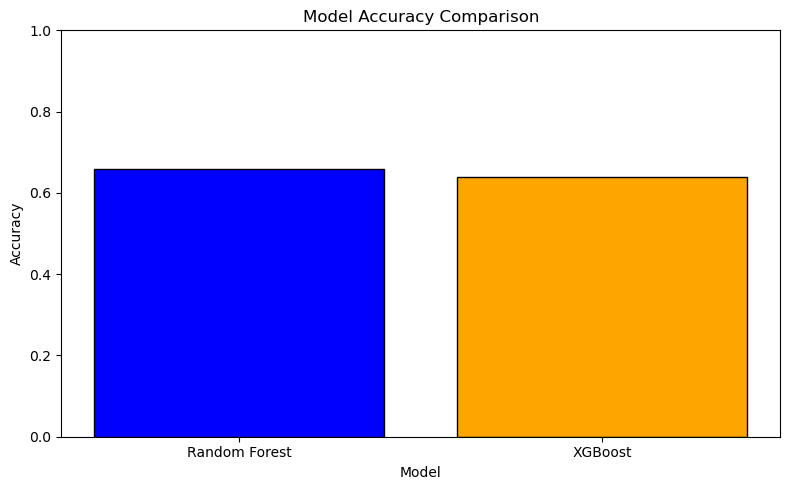

In [12]:
plt.figure(figsize=(8, 5))
plt.bar(results_df['Model'], results_df['Accuracy'],
        color=['blue', 'orange'], edgecolor='black')
plt.title('Model Accuracy Comparison')
plt.xlabel('Model')
plt.ylabel('Accuracy')
plt.ylim(0, 1)
plt.tight_layout()
plt.show()

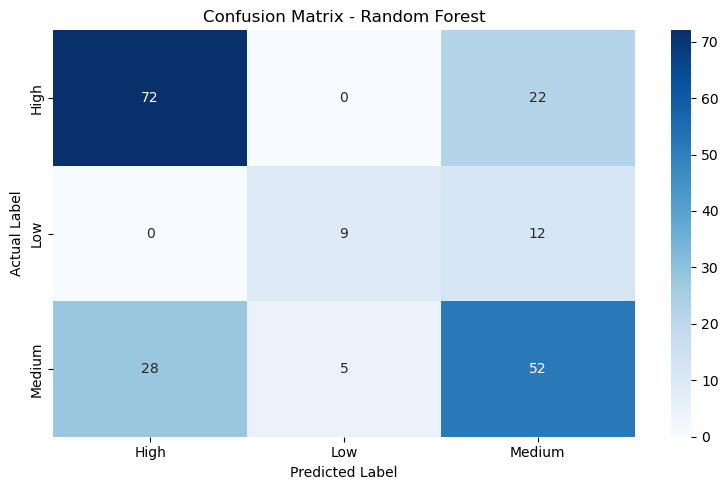

In [15]:
cm = confusion_matrix(y_test, rf_predictions)
plt.figure(figsize=(8, 5))
sns.heatmap(cm,
            annot=True,
            fmt='d',
            cmap='Blues',
            xticklabels=le.classes_,
            yticklabels=le.classes_)
plt.title('Confusion Matrix - Random Forest')
plt.xlabel('Predicted Label')
plt.ylabel('Actual Label')
plt.tight_layout()
plt.show()

In [19]:
results_df.to_csv('sprint2_model_comparison.csv', index=False)
print("Results saved")

Results saved
